
Loading Shock Tube...
  Loading: /scratch/jtb3sud/delta/shocktube/training_history.json
  Loading: /scratch/jtb3sud/delta/shocktube/run_101_300/training_history.json
  MeshGraphKAN: 200 epochs
  Loading: /scratch/jtb3sud/shocktube_v2_training/nospadeFAST/training_history.json
  G-PARC: 100 epochs

Loading River...
  Loading: /scratch/jtb3sud/delta/river/training_history.json
  Loading: /scratch/jtb3sud/delta/river/run2_51_150/training_history.json
  MeshGraphKAN: 151 epochs
  Loading: /scratch/jtb3sud/gparcv2/river/concat/20/training_history.json
  Loading: /scratch/jtb3sud/gparcv2/river/concat/training_history.json
  G-PARC: 248 epochs

Loading Elastoplastic...
  Loading: /scratch/jtb3sud/delta/elasto/training_history.json
  MeshGraphKAN: 1500 epochs
  Loading: /scratch/jtb3sud/gparcv2/elasto_nospade/training_history.json
  G-PARC: 533 epochs


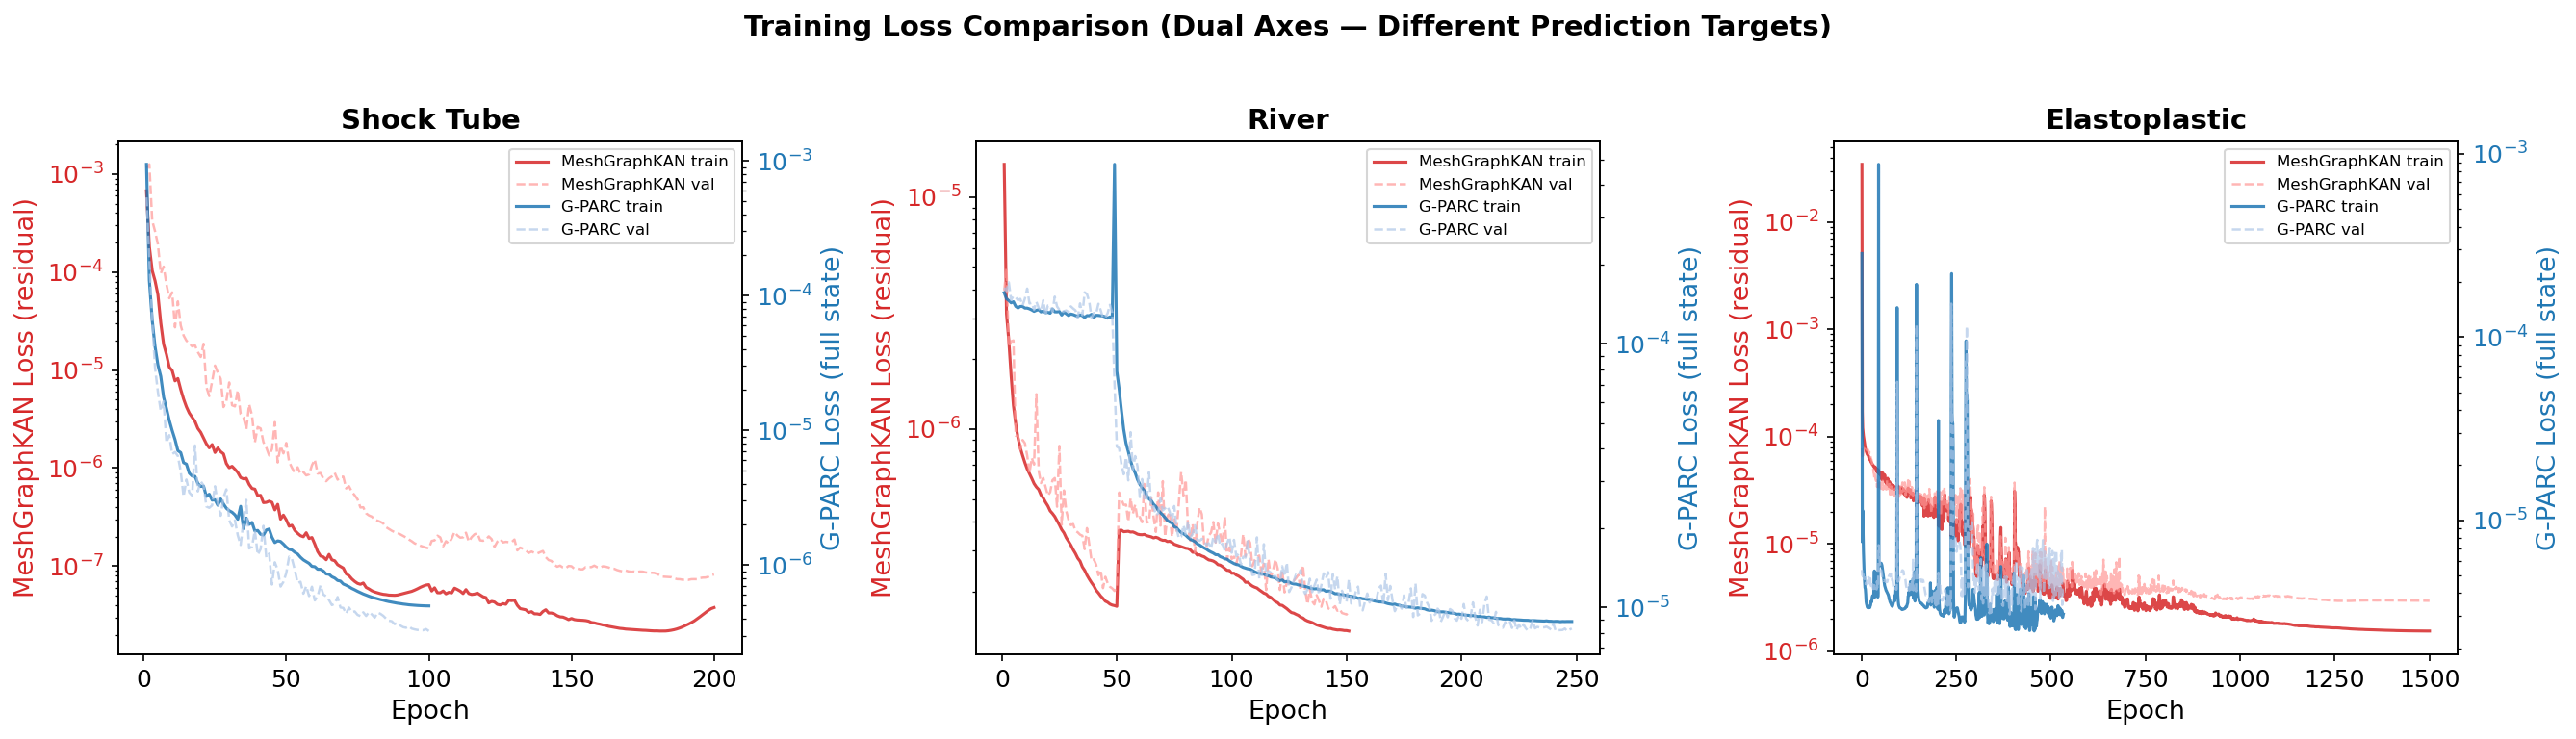

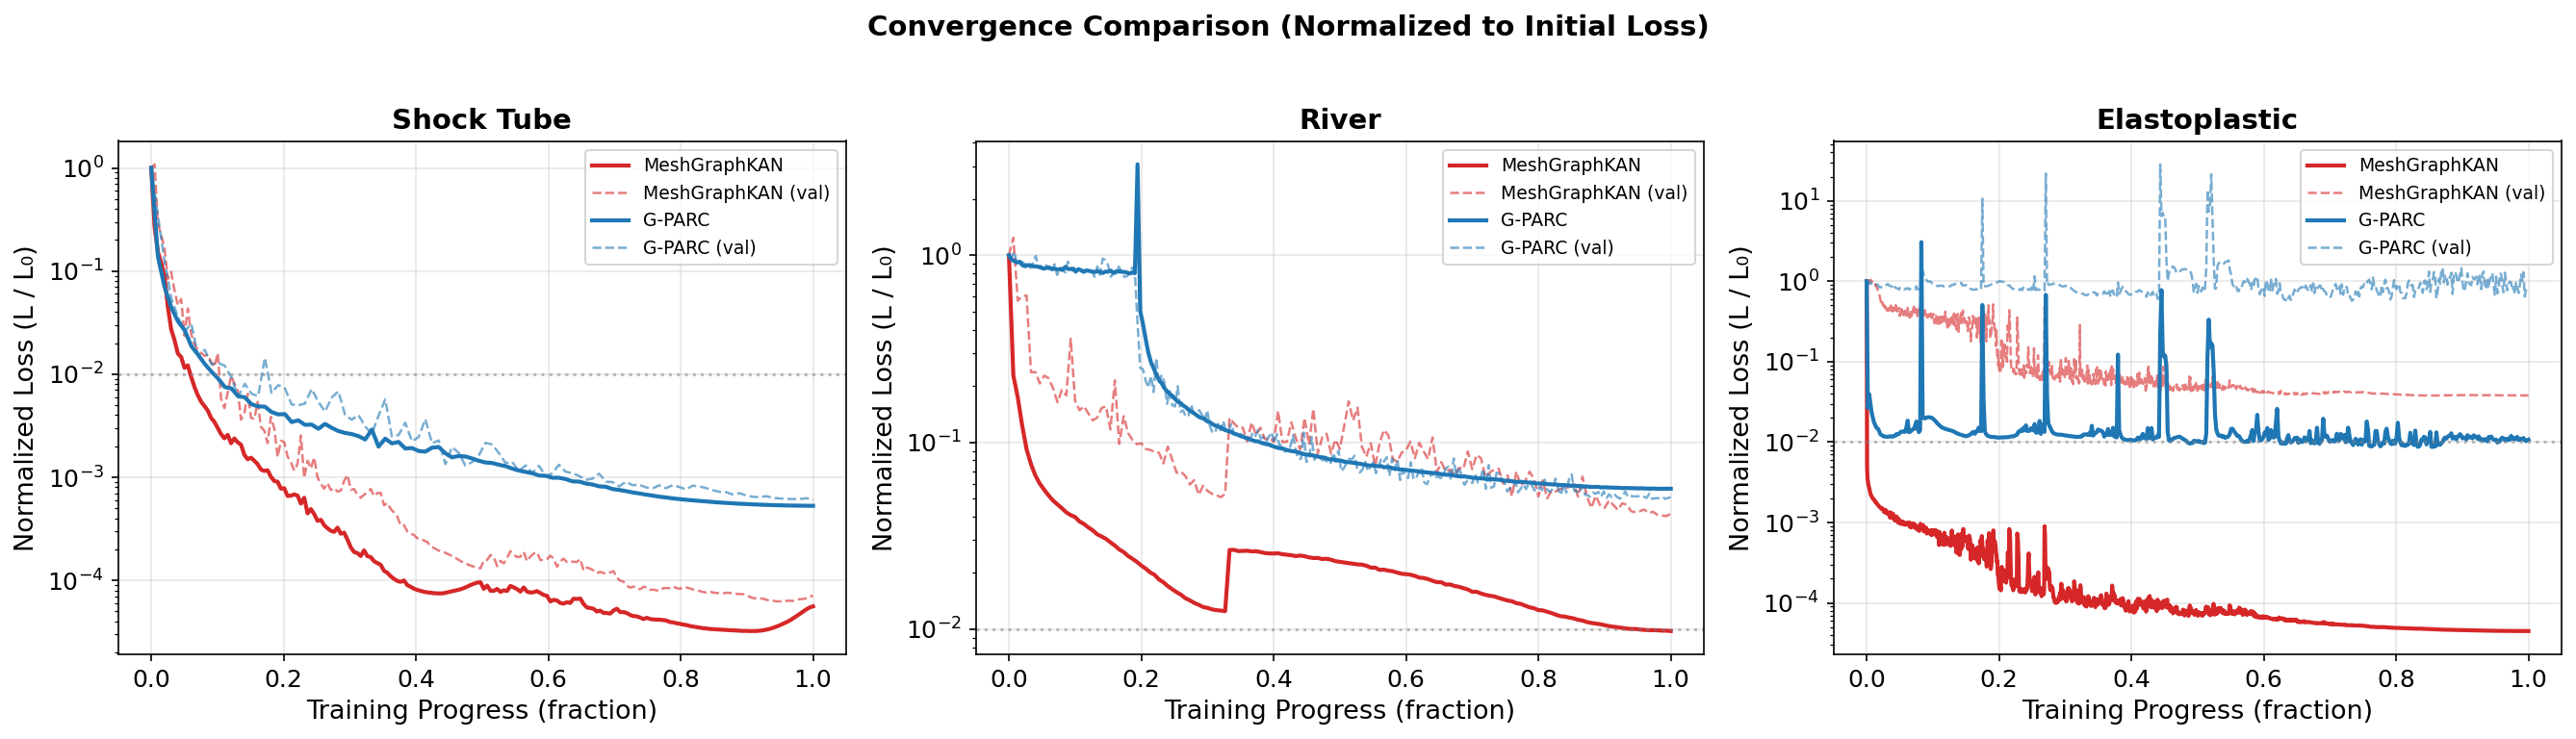

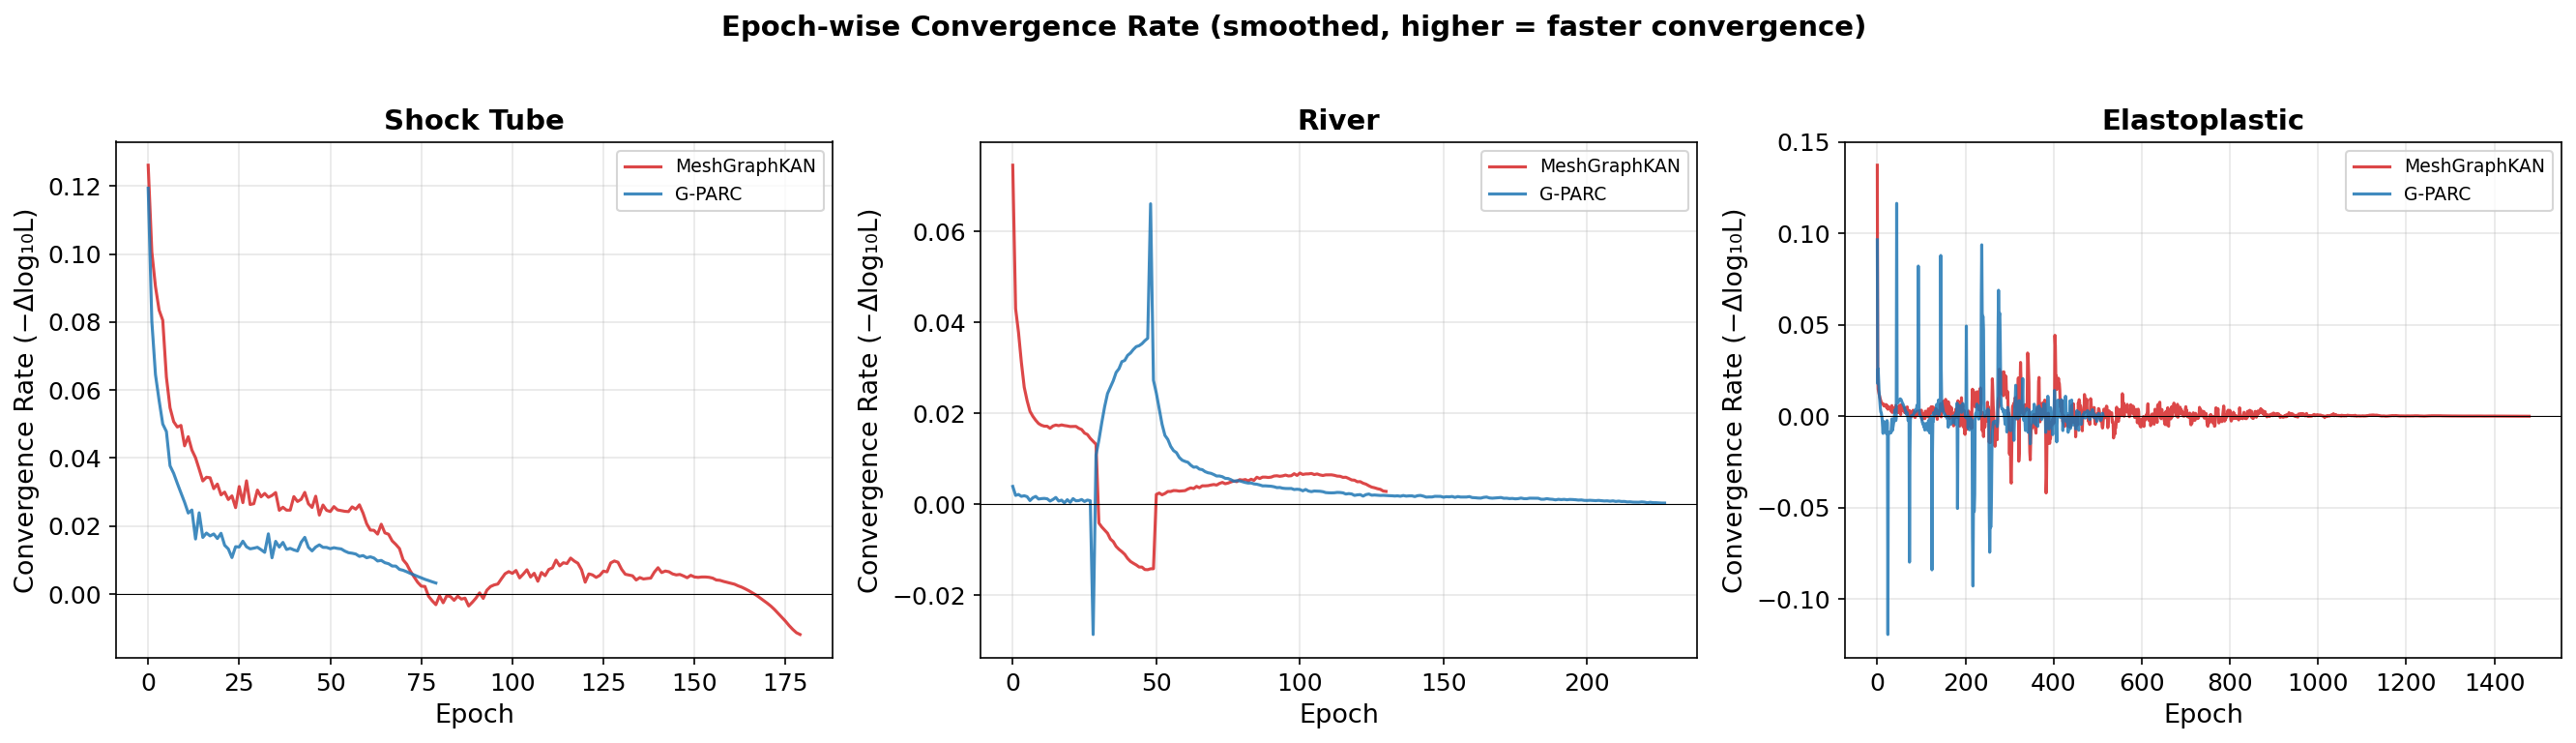

Domain             Model             Epochs   Initial Loss     Final Loss  Reduction  Orders of Mag
Shock Tube         MeshGraphKAN         200   6.742821e-04   3.776758e-08     99.99%          4.25
Shock Tube         G-PARC               100   9.418411e-04   4.980931e-07     99.95%          3.28
River              MeshGraphKAN         151   1.381224e-05   1.350270e-07     99.02%          2.01
River              G-PARC               248   1.562208e-04   8.822225e-06     94.35%          1.25
Elastoplastic      MeshGraphKAN        1500   3.452211e-02   1.544621e-06    100.00%          4.35
Elastoplastic      G-PARC               533   2.857899e-04   3.070850e-06     98.93%          1.97


In [1]:
# %% Imports and helpers
import json
import glob
import os
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

plt.rcParams.update({
    'font.size': 12,
    'axes.labelsize': 13,
    'axes.titlesize': 14,
    'legend.fontsize': 10,
    'figure.dpi': 150,
    'figure.facecolor': 'white',
})

def load_training_history(directory, label="run"):
    """Load training_history.json from a directory."""
    hist_files = sorted(glob.glob(os.path.join(directory, "**/training_history.json"), recursive=True))
    if not hist_files:
        hist_files = sorted(glob.glob(os.path.join(directory, "training_history.json")))
    if not hist_files:
        print(f"WARNING: No training_history.json found in {directory}")
        return None

    all_train_loss = []
    all_val_loss = []

    for hf in hist_files:
        print(f"  Loading: {hf}")
        with open(hf, 'r') as f:
            data = json.load(f)

        if isinstance(data, dict):
            train_loss = data.get('train_loss', data.get('training_loss', []))
            val_loss = data.get('val_loss', data.get('validation_loss', []))
        elif isinstance(data, list):
            train_loss = [d.get('train_loss', d.get('training_loss', None)) for d in data]
            val_loss = [d.get('val_loss', d.get('validation_loss', None)) for d in data]
            train_loss = [x for x in train_loss if x is not None]
            val_loss = [x for x in val_loss if x is not None]
        else:
            print(f"  Unexpected format in {hf}")
            continue

        all_train_loss.extend(train_loss)
        all_val_loss.extend(val_loss)

    return {
        'label': label,
        'train_loss': np.array(all_train_loss, dtype=float),
        'val_loss': np.array(all_val_loss, dtype=float) if all_val_loss else None,
        'epochs': np.arange(1, len(all_train_loss) + 1),
    }


def load_delta_with_resume(base_dir, subdomain, label="run"):
    """
    Load from delta directory, checking for resumed runs in subdirectories.
    Concatenates histories if a resume folder exists.
    """
    primary_dir = os.path.join(base_dir, subdomain)

    hist_files = []
    primary_hist = os.path.join(primary_dir, "training_history.json")
    if os.path.exists(primary_hist):
        hist_files.append(primary_hist)

    # Check for resumed run directories
    for pattern in ["resumed*", "resume*", "continued*", "run2*", "checkpoint*"]:
        resumed = sorted(glob.glob(os.path.join(primary_dir, pattern)))
        for rd in resumed:
            rh = os.path.join(rd, "training_history.json")
            if os.path.exists(rh):
                hist_files.append(rh)

    # Also check any subdirectories with training_history.json
    for subdir in sorted(Path(primary_dir).iterdir()) if Path(primary_dir).exists() else []:
        if subdir.is_dir():
            rh = subdir / "training_history.json"
            if rh.exists() and str(rh) not in hist_files:
                hist_files.append(str(rh))

    if not hist_files:
        print(f"WARNING: No history files found in {primary_dir}")
        return None

    all_train = []
    all_val = []
    for hf in hist_files:
        print(f"  Loading: {hf}")
        with open(hf, 'r') as f:
            data = json.load(f)
        if isinstance(data, dict):
            all_train.extend(data.get('train_loss', data.get('training_loss', [])))
            all_val.extend(data.get('val_loss', data.get('validation_loss', [])))
        elif isinstance(data, list):
            all_train.extend([d.get('train_loss', d.get('training_loss')) for d in data if 'train_loss' in d or 'training_loss' in d])
            all_val.extend([d.get('val_loss', d.get('validation_loss')) for d in data if 'val_loss' in d or 'validation_loss' in d])

    return {
        'label': label,
        'train_loss': np.array(all_train, dtype=float),
        'val_loss': np.array(all_val, dtype=float) if all_val else None,
        'epochs': np.arange(1, len(all_train) + 1),
    }


# %% Load all data
DELTA_BASE = "/scratch/jtb3sud/delta"

datasets = {
    'Shock Tube': {
        'meshgraphkan': lambda: load_delta_with_resume(DELTA_BASE, "shocktube", "MeshGraphKAN"),
        'gparc': lambda: load_training_history(
            "/scratch/jtb3sud/shocktube_v2_training/nospadeFAST", "G-PARC"),
    },
    'River': {
        'meshgraphkan': lambda: load_delta_with_resume(DELTA_BASE, "river", "MeshGraphKAN"),
        'gparc': lambda: load_training_history(
            "/scratch/jtb3sud/gparcv2/river/concat", "G-PARC"),
    },
    'Elastoplastic': {
        'meshgraphkan': lambda: load_delta_with_resume(DELTA_BASE, "elasto", "MeshGraphKAN"),
        'gparc': lambda: load_training_history(
            "/scratch/jtb3sud/gparcv2/elasto_nospade", "G-PARC"),
    },
}

loaded = {}
for domain, sources in datasets.items():
    print(f"\n{'='*50}")
    print(f"Loading {domain}...")
    loaded[domain] = {}
    for key, loader in sources.items():
        result = loader()
        if result is not None:
            loaded[domain][key] = result
            print(f"  {result['label']}: {len(result['train_loss'])} epochs")


# %% Dual-axis raw loss comparison
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

colors = {
    'meshgraphkan': {'train': '#d62728', 'val': '#ff9896'},
    'gparc':        {'train': '#1f77b4', 'val': '#aec7e8'},
}

for idx, (domain, data) in enumerate(loaded.items()):
    ax1 = axes[idx]
    ax2 = ax1.twinx()

    lines = []
    labels = []

    for key, ax, side in [('meshgraphkan', ax1, 'left'), ('gparc', ax2, 'right')]:
        if key not in data:
            continue
        d = data[key]
        c = colors[key]

        l, = ax.semilogy(d['epochs'], d['train_loss'], color=c['train'],
                         alpha=0.85, linewidth=1.5)
        lines.append(l)
        labels.append(f"{d['label']} train")

        if d['val_loss'] is not None and len(d['val_loss']) > 0:
            l, = ax.semilogy(d['epochs'], d['val_loss'], color=c['val'],
                             alpha=0.7, linewidth=1.2, linestyle='--')
            lines.append(l)
            labels.append(f"{d['label']} val")

        if side == 'left':
            ax.set_ylabel("MeshGraphKAN Loss (residual)", color=c['train'])
            ax.tick_params(axis='y', labelcolor=c['train'])
        else:
            ax.set_ylabel("G-PARC Loss (full state)", color=c['train'])
            ax.tick_params(axis='y', labelcolor=c['train'])

    ax1.set_xlabel("Epoch")
    ax1.set_title(domain, fontweight='bold')
    ax1.legend(lines, labels, loc='upper right', fontsize=8)

fig.suptitle("Training Loss Comparison (Dual Axes — Different Prediction Targets)",
             fontweight='bold', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig("loss_comparison_dual_axis.png", dpi=200, bbox_inches='tight')
plt.show()


# %% Normalized convergence (L / L_0)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, (domain, data) in enumerate(loaded.items()):
    ax = axes[idx]

    for key in ['meshgraphkan', 'gparc']:
        if key not in data:
            continue
        d = data[key]
        c = colors[key]['train']

        train_norm = d['train_loss'] / d['train_loss'][0]
        progress = np.linspace(0, 1, len(train_norm))

        ax.semilogy(progress, train_norm, color=c, linewidth=2, label=d['label'])

        if d['val_loss'] is not None and len(d['val_loss']) > 0:
            val_norm = d['val_loss'] / d['val_loss'][0]
            progress_v = np.linspace(0, 1, len(val_norm))
            ax.semilogy(progress_v, val_norm, color=c, linewidth=1.2,
                        linestyle='--', alpha=0.6, label=f"{d['label']} (val)")

    ax.set_xlabel("Training Progress (fraction)")
    ax.set_ylabel("Normalized Loss (L / L₀)")
    ax.set_title(domain, fontweight='bold')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)
    ax.axhline(y=0.01, color='gray', linestyle=':', alpha=0.5)

fig.suptitle("Convergence Comparison (Normalized to Initial Loss)",
             fontweight='bold', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig("loss_comparison_normalized.png", dpi=200, bbox_inches='tight')
plt.show()


# %% Convergence rate analysis
def smoothed_convergence_rate(loss, window=20):
    """Smoothed epoch-over-epoch relative improvement in log space."""
    log_loss = np.log10(loss + 1e-15)
    rate = -np.diff(log_loss)
    if len(rate) > window:
        kernel = np.ones(window) / window
        rate = np.convolve(rate, kernel, mode='valid')
    return rate

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, (domain, data) in enumerate(loaded.items()):
    ax = axes[idx]

    for key in ['meshgraphkan', 'gparc']:
        if key not in data:
            continue
        d = data[key]
        c = colors[key]['train']

        rate = smoothed_convergence_rate(d['train_loss'])
        epochs = np.arange(len(rate))
        ax.plot(epochs, rate, color=c, linewidth=1.5, label=d['label'], alpha=0.85)

    ax.set_xlabel("Epoch")
    ax.set_ylabel("Convergence Rate (−Δlog₁₀L)")
    ax.set_title(domain, fontweight='bold')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)
    ax.axhline(y=0, color='black', linewidth=0.5)

fig.suptitle("Epoch-wise Convergence Rate (smoothed, higher = faster convergence)",
             fontweight='bold', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig("loss_comparison_rate.png", dpi=200, bbox_inches='tight')
plt.show()


# %% Summary table
print(f"{'Domain':<18} {'Model':<16} {'Epochs':>7} {'Initial Loss':>14} {'Final Loss':>14} {'Reduction':>10} {'Orders of Mag':>14}")
print("=" * 100)

for domain, data in loaded.items():
    for key in ['meshgraphkan', 'gparc']:
        if key not in data:
            continue
        d = data[key]
        init = d['train_loss'][0]
        final = d['train_loss'][-1]
        reduction = (1 - final/init) * 100
        orders = np.log10(init / final)
        print(f"{domain:<18} {d['label']:<16} {len(d['train_loss']):>7} {init:>14.6e} {final:>14.6e} {reduction:>9.2f}% {orders:>13.2f}")

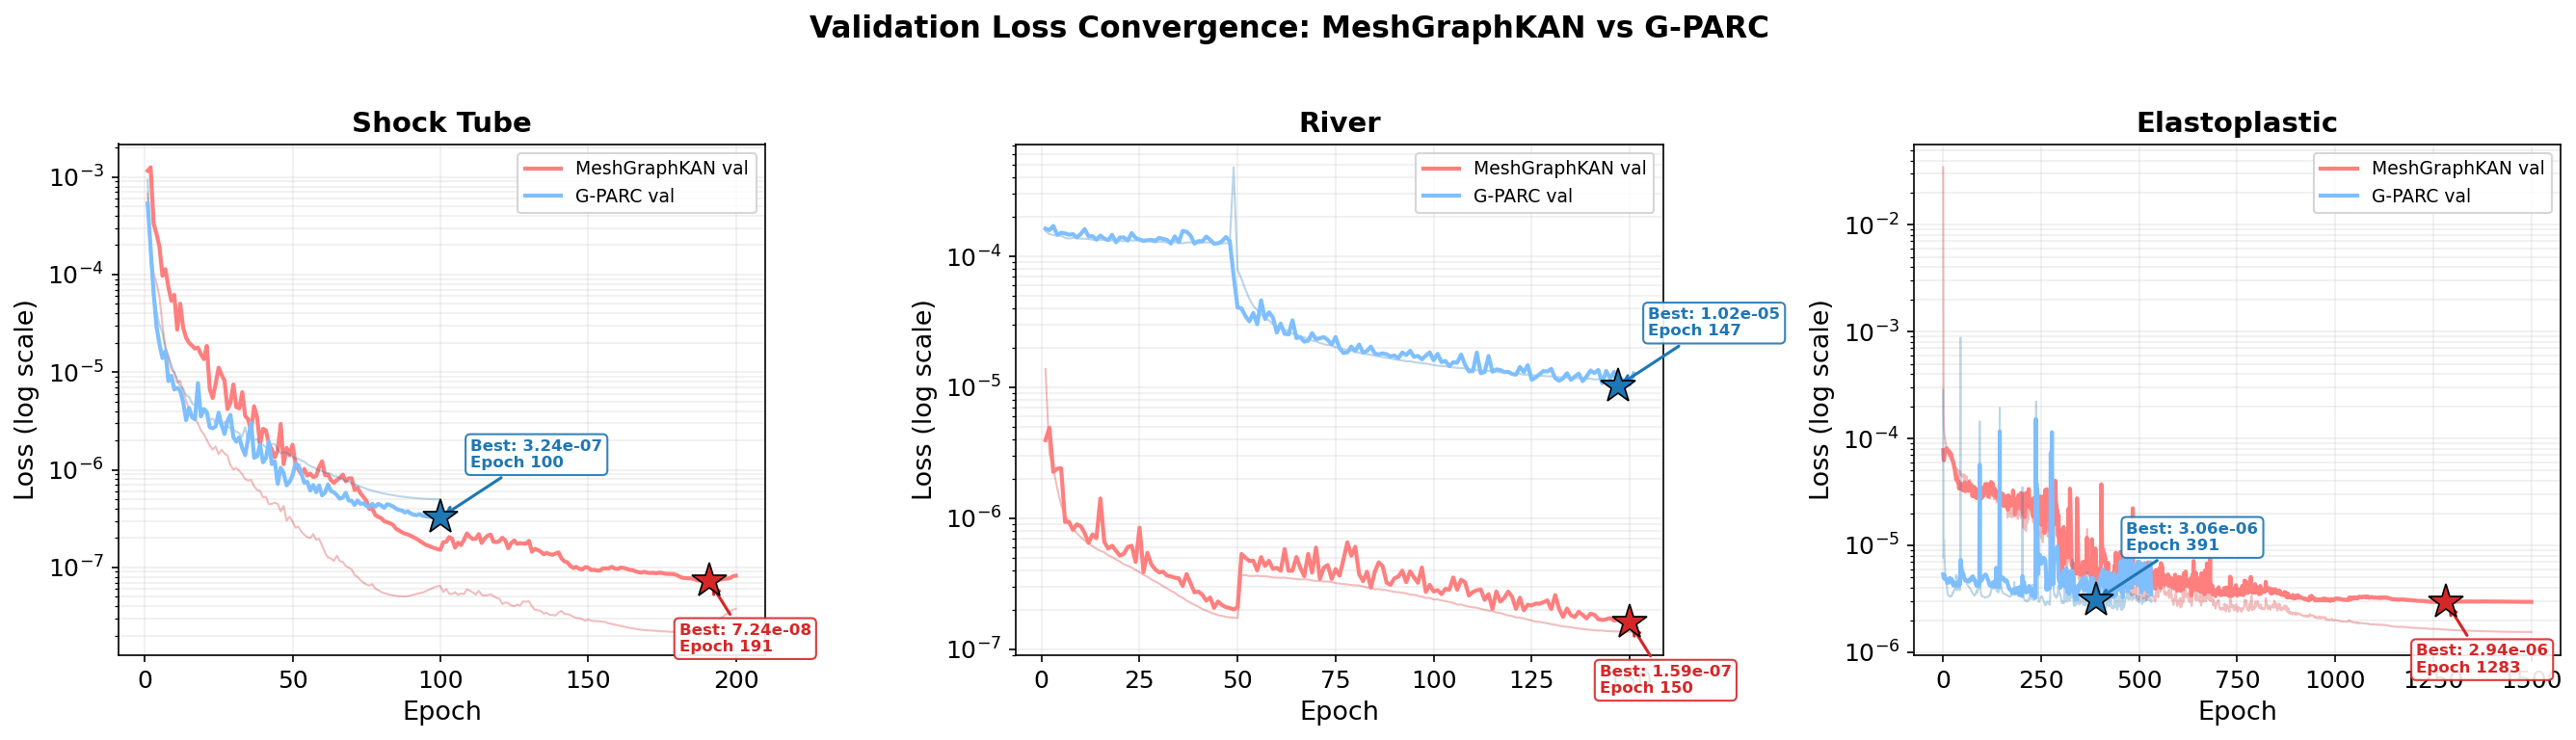

In [2]:
# %% Best validation loss comparison
import numpy as np
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

colors = {
    'meshgraphkan': {'train': '#d62728', 'val': '#ff7f7f'},
    'gparc':        {'train': '#1f77b4', 'val': '#7fbfff'},
}

for idx, (domain, data) in enumerate(loaded.items()):
    ax = axes[idx]

    # Determine max epochs to show (cap to meshgraphkan length if both exist)
    max_epoch = None
    if domain == 'River' and 'meshgraphkan' in data:
        max_epoch = len(data['meshgraphkan']['train_loss'])

    for key in ['meshgraphkan', 'gparc']:
        if key not in data:
            continue
        d = data[key]
        c = colors[key]

        # Truncate to max_epoch if set
        n = max_epoch if max_epoch else len(d['train_loss'])
        epochs = d['epochs'][:n]
        train = d['train_loss'][:n]

        ax.semilogy(epochs, train, color=c['train'],
                    alpha=0.3, linewidth=1)

        if d['val_loss'] is not None and len(d['val_loss']) > 0:
            val_n = min(n, len(d['val_loss']))
            val_epochs = d['epochs'][:val_n]
            val_loss = d['val_loss'][:val_n]

            ax.semilogy(val_epochs, val_loss,
                        color=c['val'], linewidth=2, label=f"{d['label']} val")

            best_idx = np.argmin(val_loss)
            best_val = val_loss[best_idx]
            best_epoch = val_epochs[best_idx]

            ax.plot(best_epoch, best_val, marker='*', markersize=18,
                    color=c['train'], zorder=5, markeredgecolor='black',
                    markeredgewidth=0.8)

            offset = (15, 25) if key == 'gparc' else (-15, -35)
            ax.annotate(f"Best: {best_val:.2e}\nEpoch {best_epoch}",
                        xy=(best_epoch, best_val),
                        xytext=offset, textcoords='offset points',
                        fontsize=8, fontweight='bold', color=c['train'],
                        arrowprops=dict(arrowstyle='->', color=c['train'], lw=1.5),
                        bbox=dict(boxstyle='round,pad=0.3', facecolor='white',
                                  edgecolor=c['train'], alpha=0.9))

    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss (log scale)")
    ax.set_title(domain, fontweight='bold', fontsize=14)
    ax.legend(fontsize=9, loc='upper right')
    ax.grid(True, alpha=0.2, which='both')

fig.suptitle("Validation Loss Convergence: MeshGraphKAN vs G-PARC",
             fontweight='bold', fontsize=15, y=1.02)
plt.tight_layout()
plt.savefig("best_validation_comparison.png", dpi=200, bbox_inches='tight')
plt.show()

In [7]:
"""
PIGNN Loss Function Analysis
=============================
Reconstructed from: Zhang et al., "Combining physics-informed graph neural network 
and finite difference for solving forward and inverse spatiotemporal PDEs" (2024)
Published in: Computer Physics Communications (arXiv: 2405.20000)

Purpose: Annotated pseudocode showing the PIGNN loss structure and where
mesh-dependence enters, limiting generalization to unseen meshes.
"""

import numpy as np


# =============================================================================
# PART 1: Finite-Difference Differential Operators on Graphs
# =============================================================================
# Zhang et al. approximate spatial derivatives using FD + OLS on the graph.
#
# For node i with neighbors j in N(i), the operator is:
#     D_i = (A^T A)^{-1} A^T    (OLS solution)
#
# where A is the Taylor expansion matrix built from relative positions.
#
# *** CRITICAL: A is ENTIRELY determined by mesh geometry ***
# *** The GNN learns weights co-optimized with these specific D_i ***
# *** On a new mesh, D_i changes but GNN weights are frozen ***


# =============================================================================
# PART 2: The PIGNN Loss Structure (from the paper)
# =============================================================================
#
# Total loss = L_pde + lambda_ic * L_ic + lambda_bc * L_bc [+ lambda_data * L_data]
#
# L_pde  = (1/T) Sum_t (1/N) Sum_i || F(u, du/dt, du/dx, d2u/dx2, ...) ||^2
# L_ic   = (1/N) Sum_i || u_pred(x_i, 0) - u_0(x_i) ||^2  
# L_bc   = (1/N_bc) Sum_i || B(u_pred) ||^2
# L_data = (1/N_d) Sum_i || u_pred - u_obs ||^2   (inverse problems only)
#
# The KEY mesh-dependent component is in L_pde:
#   - du/dt is computed via forward Euler: (u^{n+1} - u^n) / dt
#   - du/dx, d2u/dx2 are computed via the FD operators D_i
#   - D_i are FIXED by mesh geometry
#   - GNN weights theta were optimized for THESE SPECIFIC D_i
#
# Pseudocode for the PDE loss computation:
#
#   for t in range(T-1):
#       u_curr = gnn_predict(graph, t)        # GNN output (learned)
#       u_next = gnn_predict(graph, t+1)      # GNN output (learned)
#       du_dt = (u_next - u_curr) / dt        # temporal FD
#
#       for each node i:
#           u_diff = u[neighbors_i] - u[i]    # neighbor differences
#           derivs = D_i @ u_diff             # spatial FD via OLS stencil
#           # derivs = [du/dx, du/dy, d2u/dx2, d2u/dxdy, d2u/dy2]
#
#           residual_i = PDE(u[i], du_dt[i], derivs)
#
#       L_pde += mean(residual^2)


# =============================================================================
# PART 3: Numerical Demo -- FD operator sensitivity to mesh
# =============================================================================

def demo_fd_sensitivity():
    """Show how FD stencil weights change with mesh geometry."""
    
    print("=" * 70)
    print("FD OPERATOR SENSITIVITY TO MESH GEOMETRY")
    print("=" * 70)
    print()
    
    # --- 1D Examples ---
    print("1D EXAMPLES: du/dx stencil weights for different meshes")
    print("-" * 70)
    
    cases = [
        ("Uniform (neighbors at -1.0, +1.0)", np.array([-1.0, 1.0])),
        ("Non-uniform (neighbors at -0.5, +2.0)", np.array([-0.5, 2.0])),
        ("Highly graded (neighbors at -0.1, +3.0)", np.array([-0.1, 3.0])),
    ]
    
    for name, dx in cases:
        A = dx.reshape(-1, 1)
        w = np.linalg.lstsq(A, np.eye(2), rcond=None)[0].flatten()
        print(f"  {name}")
        print(f"    Stencil weights: [{w[0]:.4f}, {w[1]:.4f}]")
        print()
    
    # --- 2D Condition Number Example ---
    print("-" * 70)
    print("2D EXAMPLE: OLS condition number vs. mesh quality")
    print("-" * 70)
    print()
    
    # Good mesh: roughly equilateral neighborhood
    nbrs_good = np.array([
        [1.0, 0.0], [-0.5, 0.866], [-0.5, -0.866],
        [0.0, 1.0], [1.0, 1.0],
    ])
    A_good = np.column_stack([
        nbrs_good[:, 0], nbrs_good[:, 1],
        0.5 * nbrs_good[:, 0]**2,
        nbrs_good[:, 0] * nbrs_good[:, 1],
        0.5 * nbrs_good[:, 1]**2,
    ])
    cond_good = np.linalg.cond(A_good)
    
    # Bad mesh: highly stretched elements
    nbrs_bad = np.array([
        [10.0, 0.01], [-10.0, 0.01], [10.0, -0.01],
        [-10.0, -0.01], [0.0, 0.02],
    ])
    A_bad = np.column_stack([
        nbrs_bad[:, 0], nbrs_bad[:, 1],
        0.5 * nbrs_bad[:, 0]**2,
        nbrs_bad[:, 0] * nbrs_bad[:, 1],
        0.5 * nbrs_bad[:, 1]**2,
    ])
    cond_bad = np.linalg.cond(A_bad)
    
    print(f"  Well-shaped neighborhood:       cond(A) = {cond_good:.1f}")
    print(f"  Highly anisotropic neighborhood: cond(A) = {cond_bad:.1f}")
    print(f"  Condition number ratio: {cond_bad/cond_good:.0f}x worse")
    print()
    
    # --- Summary ---
    print("=" * 70)
    print("KEY TAKEAWAY FOR THE LAB:")
    print("=" * 70)
    print("""
PIGNN's loss function computes PDE residuals using FD operators (D_i) 
that are entirely determined by mesh geometry. The GNN's learned weights 
are co-optimized with these specific operators during training.

On an unseen mesh:
  1. D_i changes (new neighbor positions -> new stencil weights)
  2. Graph topology changes (different adjacency structure)
  3. GNN weights are FROZEN -- optimized for the OLD operators
  -> No guarantee the GNN + new operators still minimize PDE residuals

This is fundamentally a SOFT constraint problem:
  PIGNN:  physics in the LOSS  -> soft constraint on learned GNN
  G-PARC: physics in the ARCH  -> hard constraint on the operator

When you change the mesh:
  - A soft constraint (loss-based) needs RE-OPTIMIZATION
  - A hard constraint (architecture-based) TRANSFERS because the physics 
    is encoded in the operator structure, not the graph weights

Additionally, poor mesh quality (high aspect ratios, skewed elements)
leads to ill-conditioned OLS systems (see condition numbers above),
making the FD operators themselves unreliable -- a limitation PIGNN 
inherits directly from classical finite differences.

G-PARC's MLS-based operators are more robust to mesh quality and
its physics-aware convolution kernels are defined in terms of 
differential operators that adapt to ANY mesh by construction.
""")


if __name__ == "__main__":
    demo_fd_sensitivity()

FD OPERATOR SENSITIVITY TO MESH GEOMETRY

1D EXAMPLES: du/dx stencil weights for different meshes
----------------------------------------------------------------------
  Uniform (neighbors at -1.0, +1.0)
    Stencil weights: [-0.5000, 0.5000]

  Non-uniform (neighbors at -0.5, +2.0)
    Stencil weights: [-0.1176, 0.4706]

  Highly graded (neighbors at -0.1, +3.0)
    Stencil weights: [-0.0111, 0.3330]

----------------------------------------------------------------------
2D EXAMPLE: OLS condition number vs. mesh quality
----------------------------------------------------------------------

  Well-shaped neighborhood:       cond(A) = 12.8
  Highly anisotropic neighborhood: cond(A) = 707115.6
  Condition number ratio: 55082x worse

KEY TAKEAWAY FOR THE LAB:

PIGNN's loss function computes PDE residuals using FD operators (D_i) 
that are entirely determined by mesh geometry. The GNN's learned weights 
are co-optimized with these specific operators during training.

On an unseen mesh:
 

/tmp/ipykernel_466032/2660123150.py:254: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 1, 0.93])


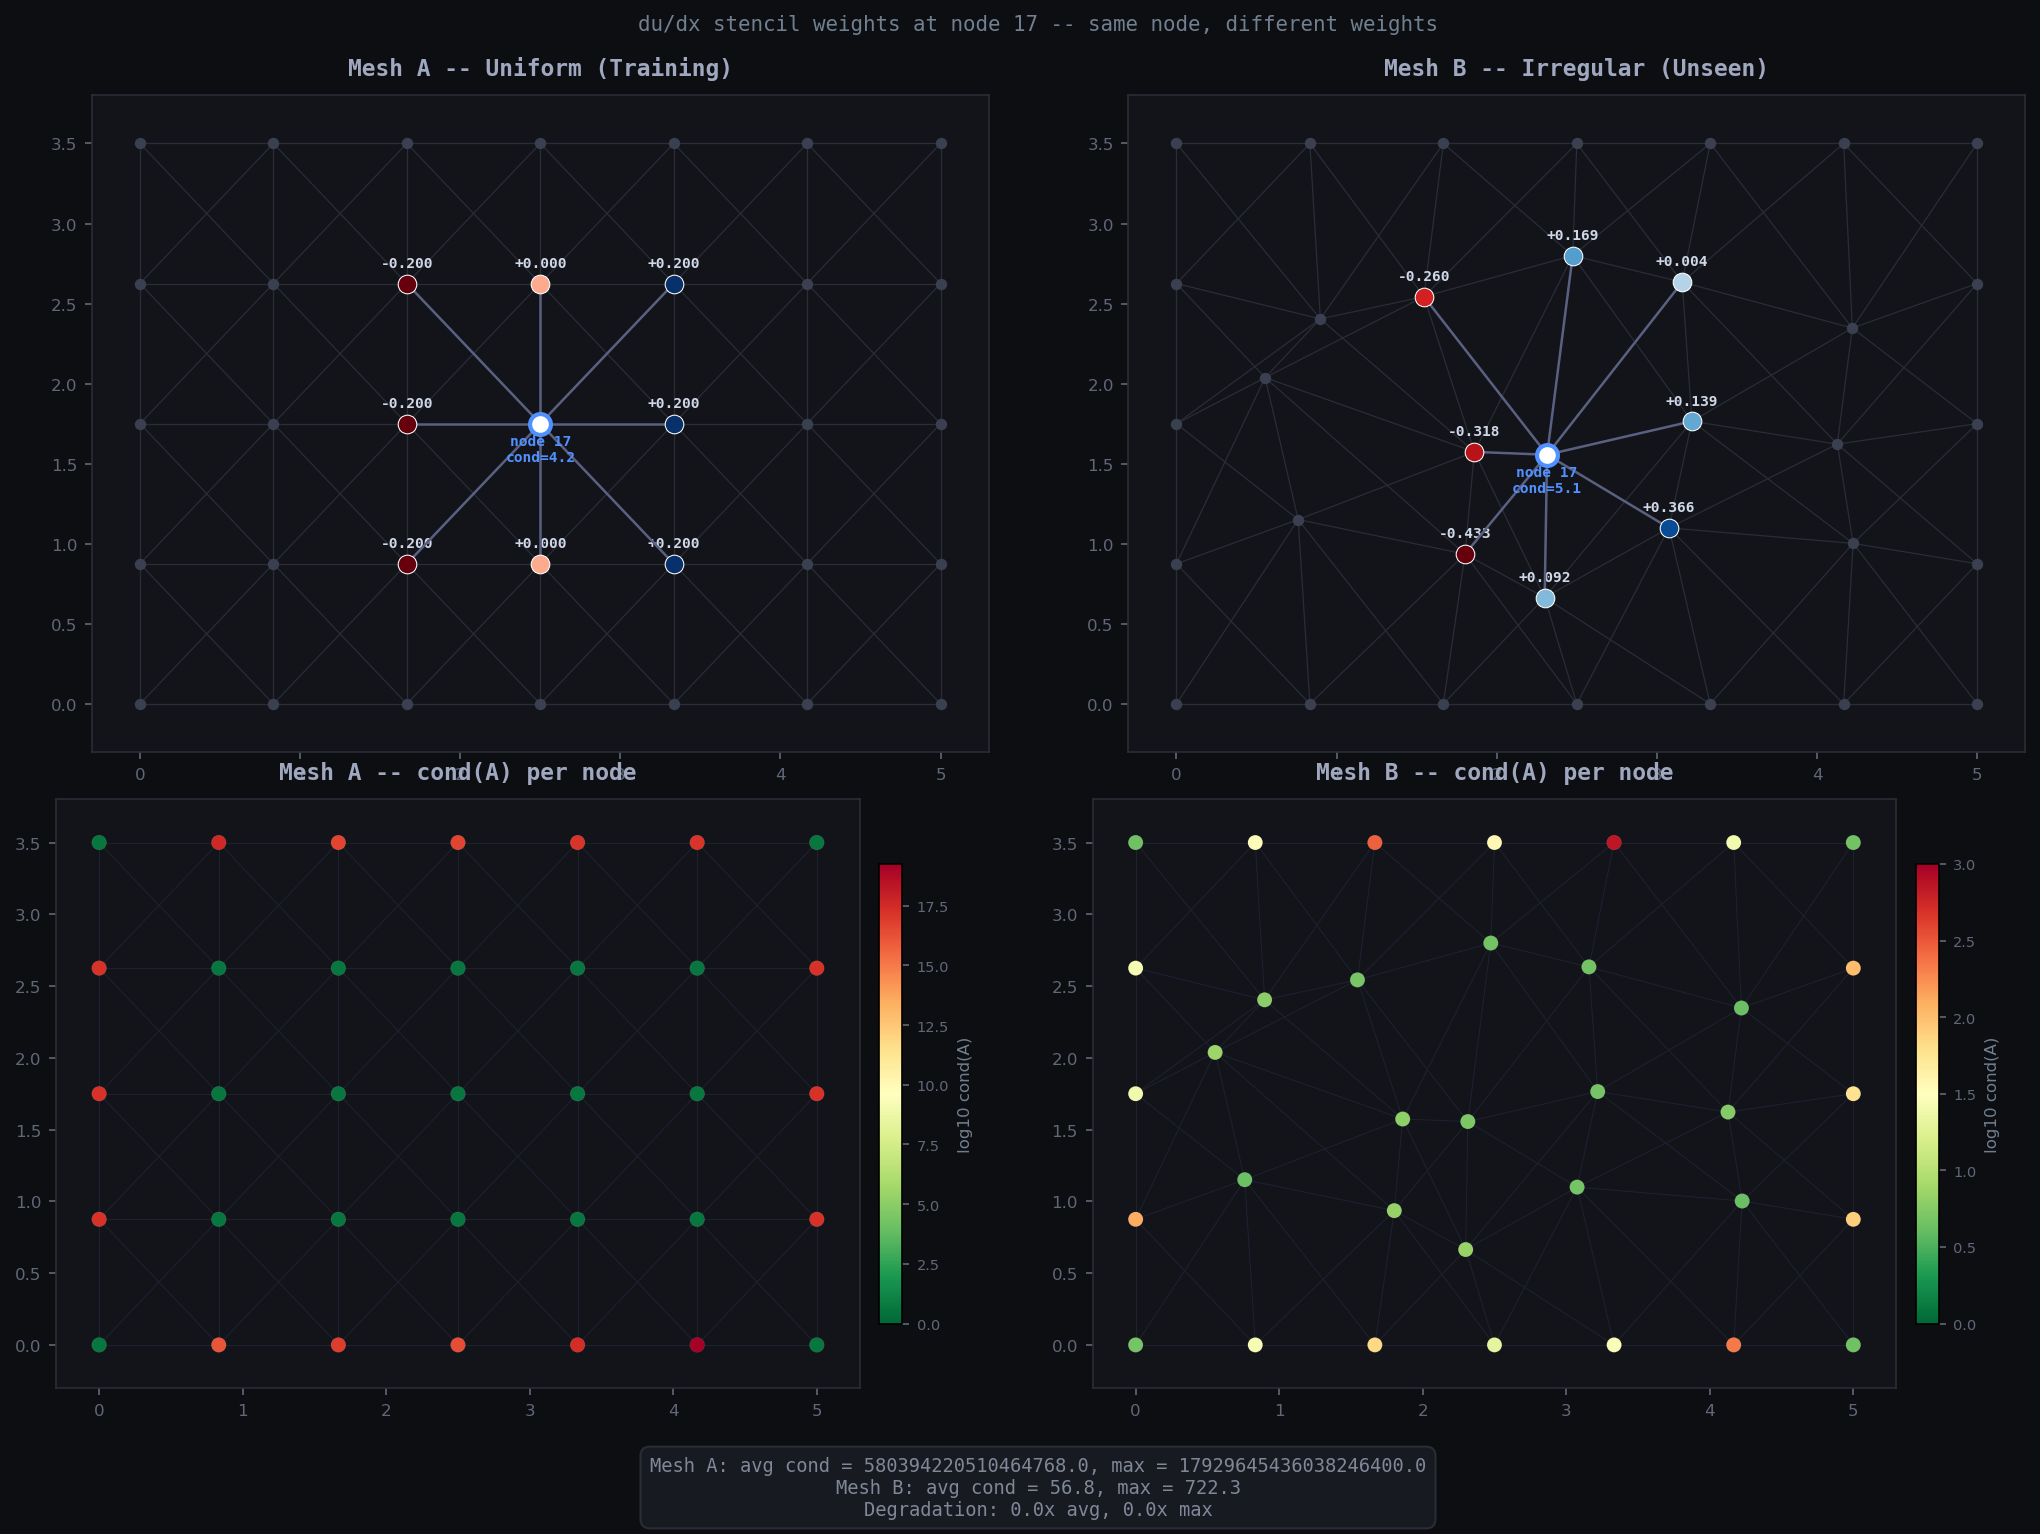

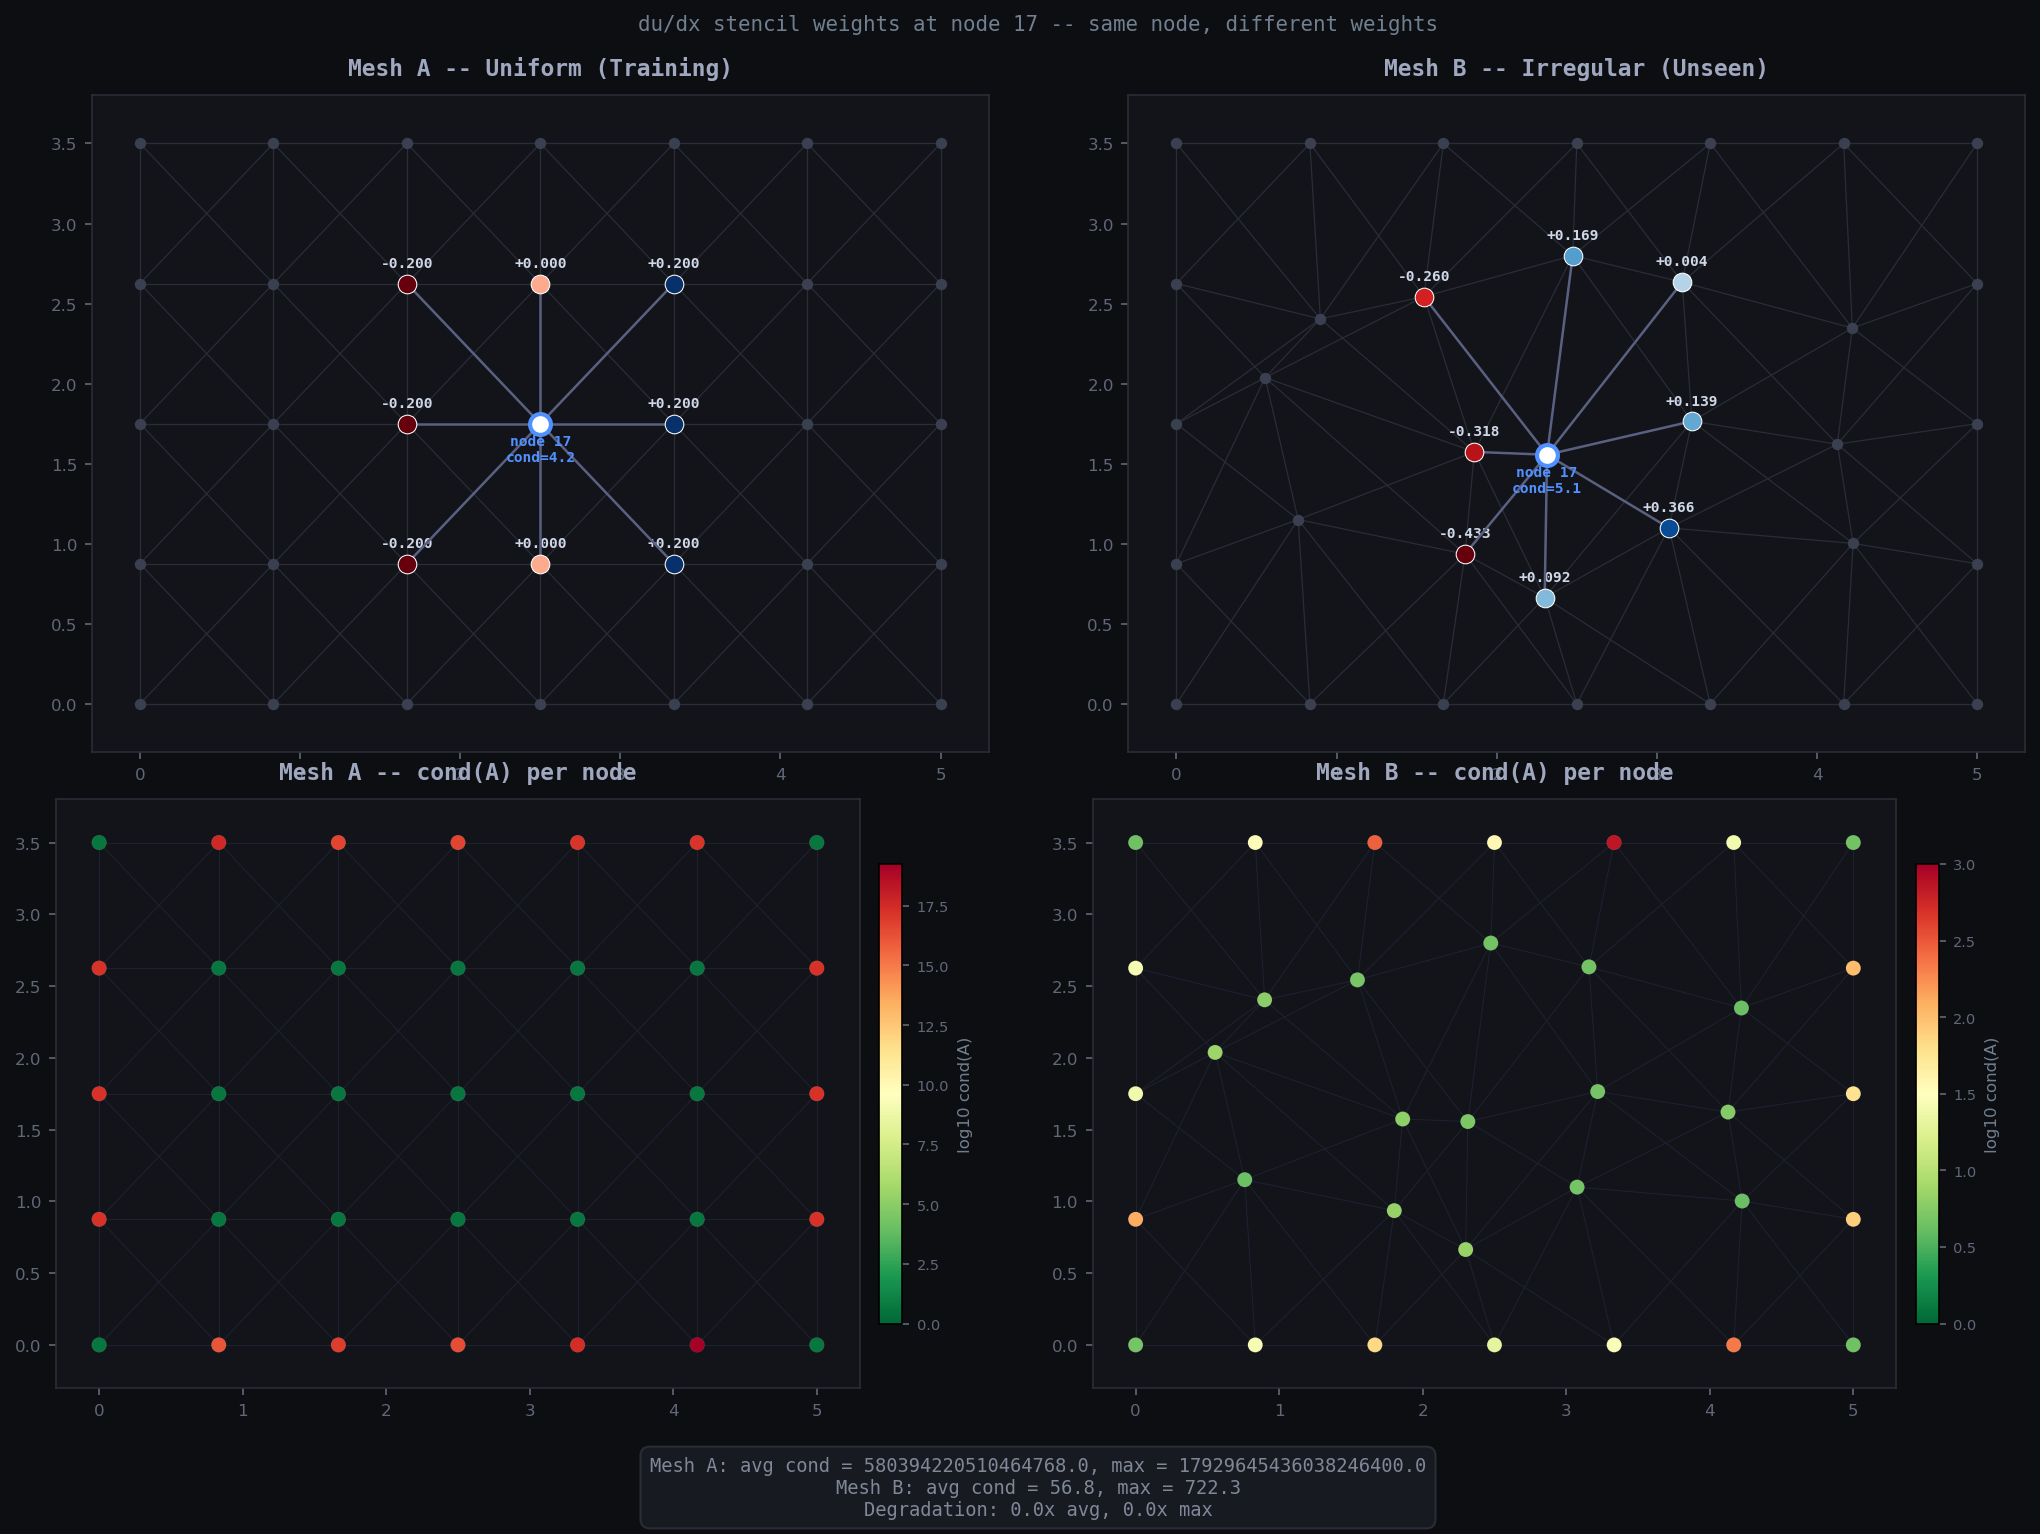

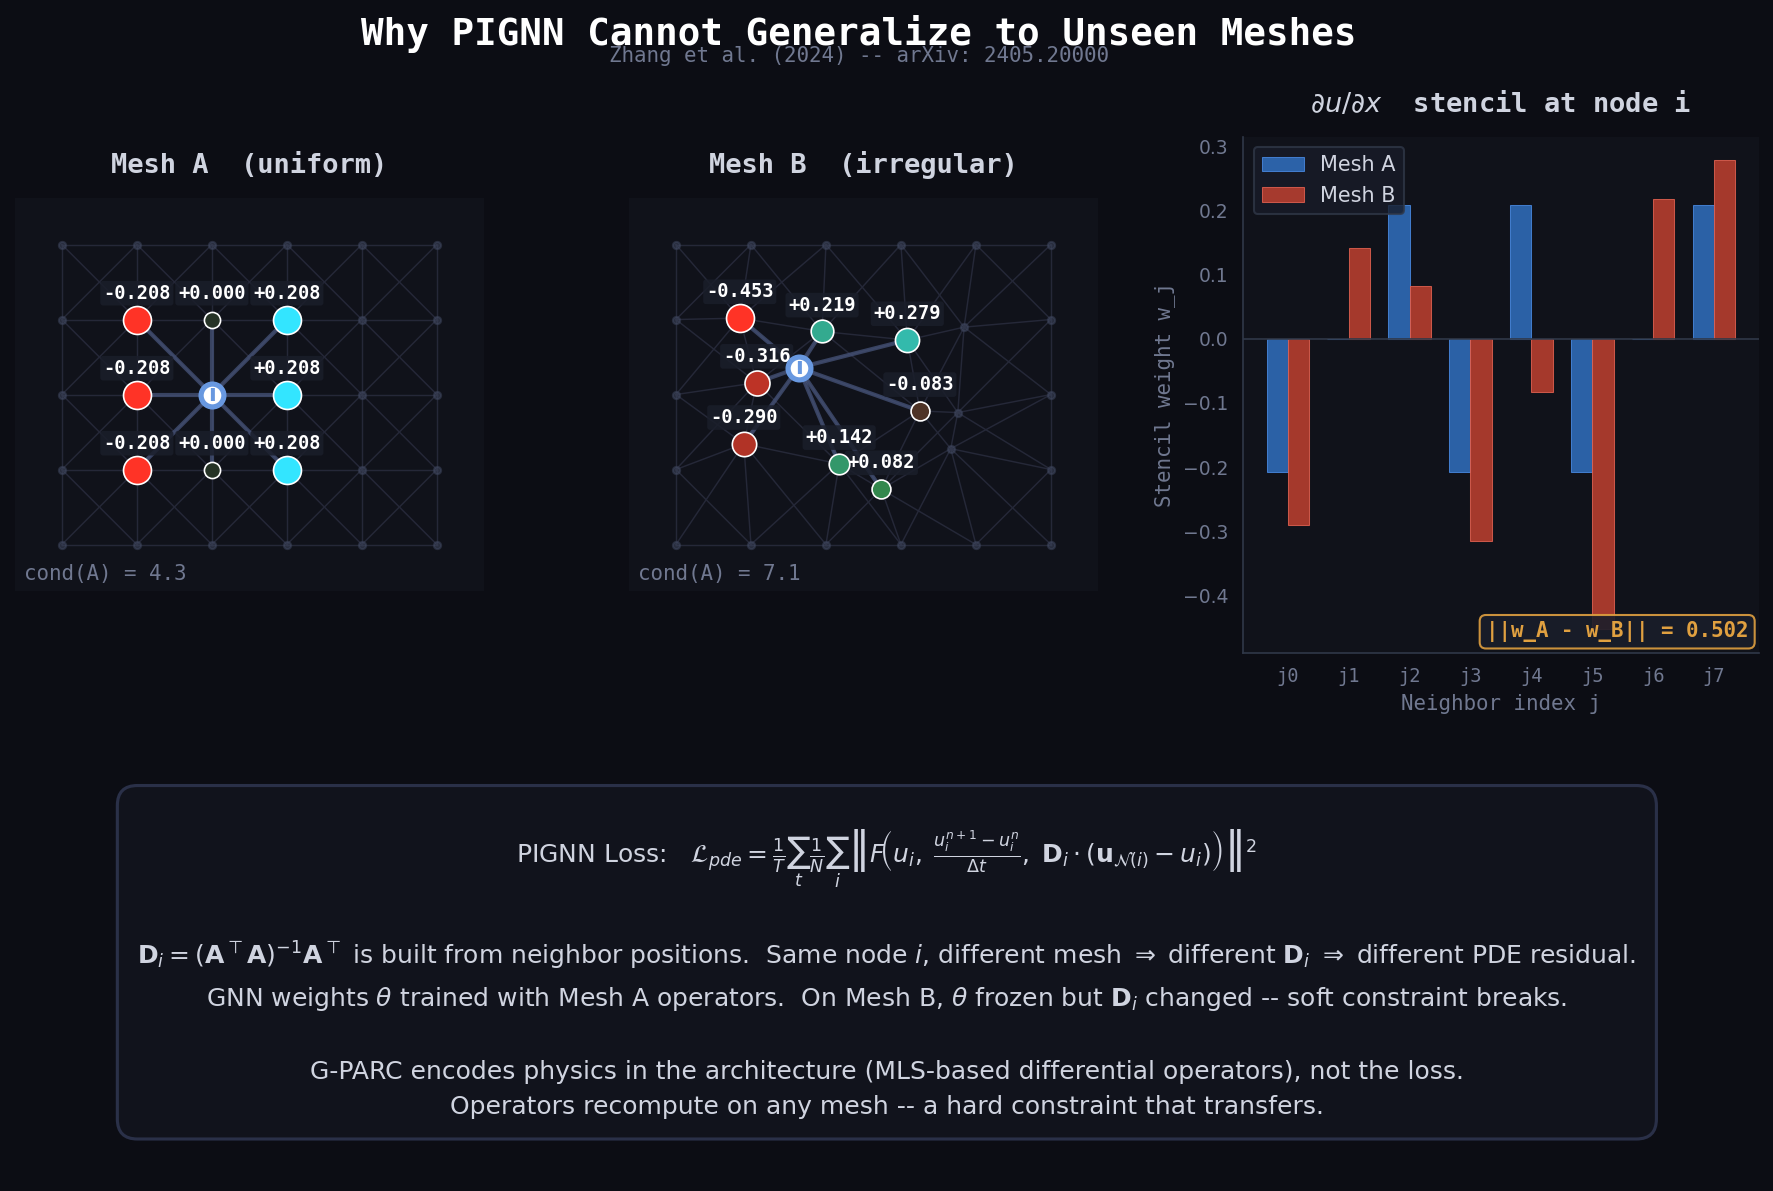

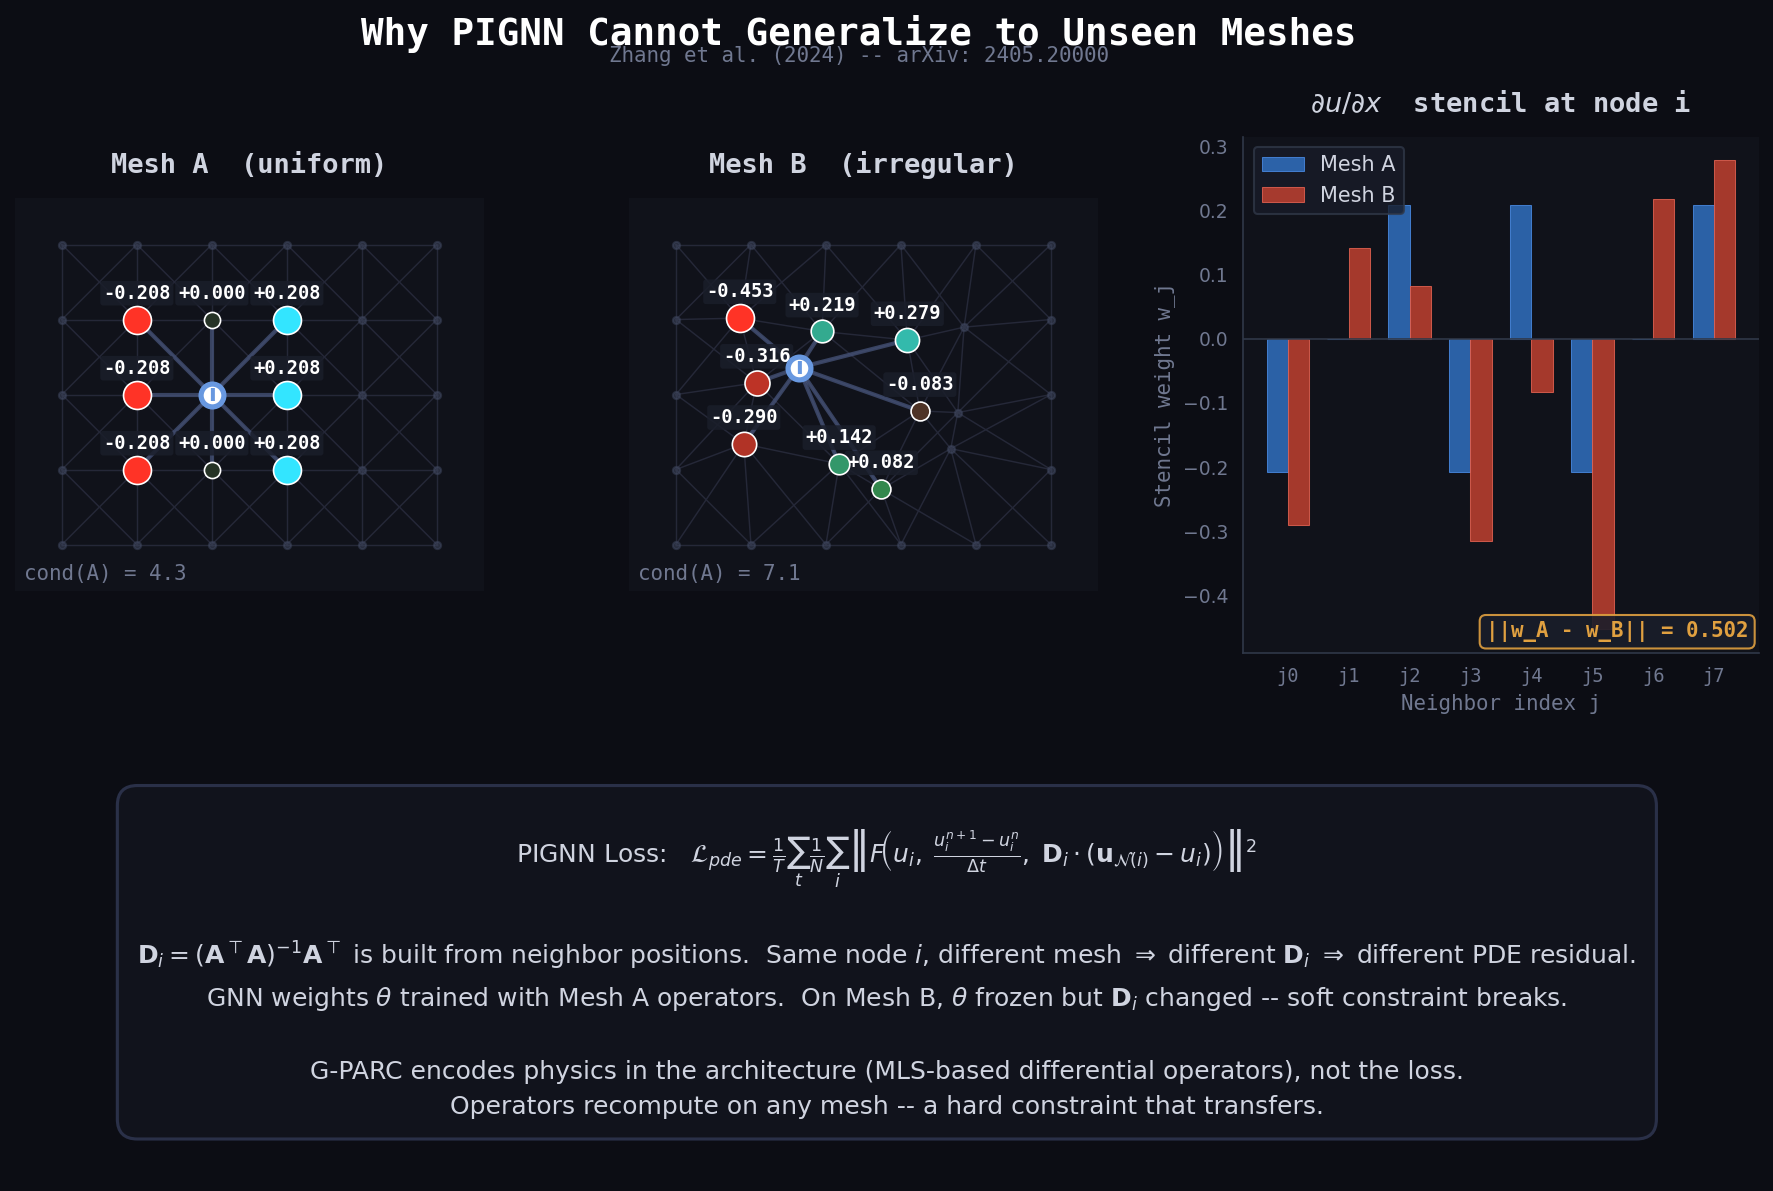

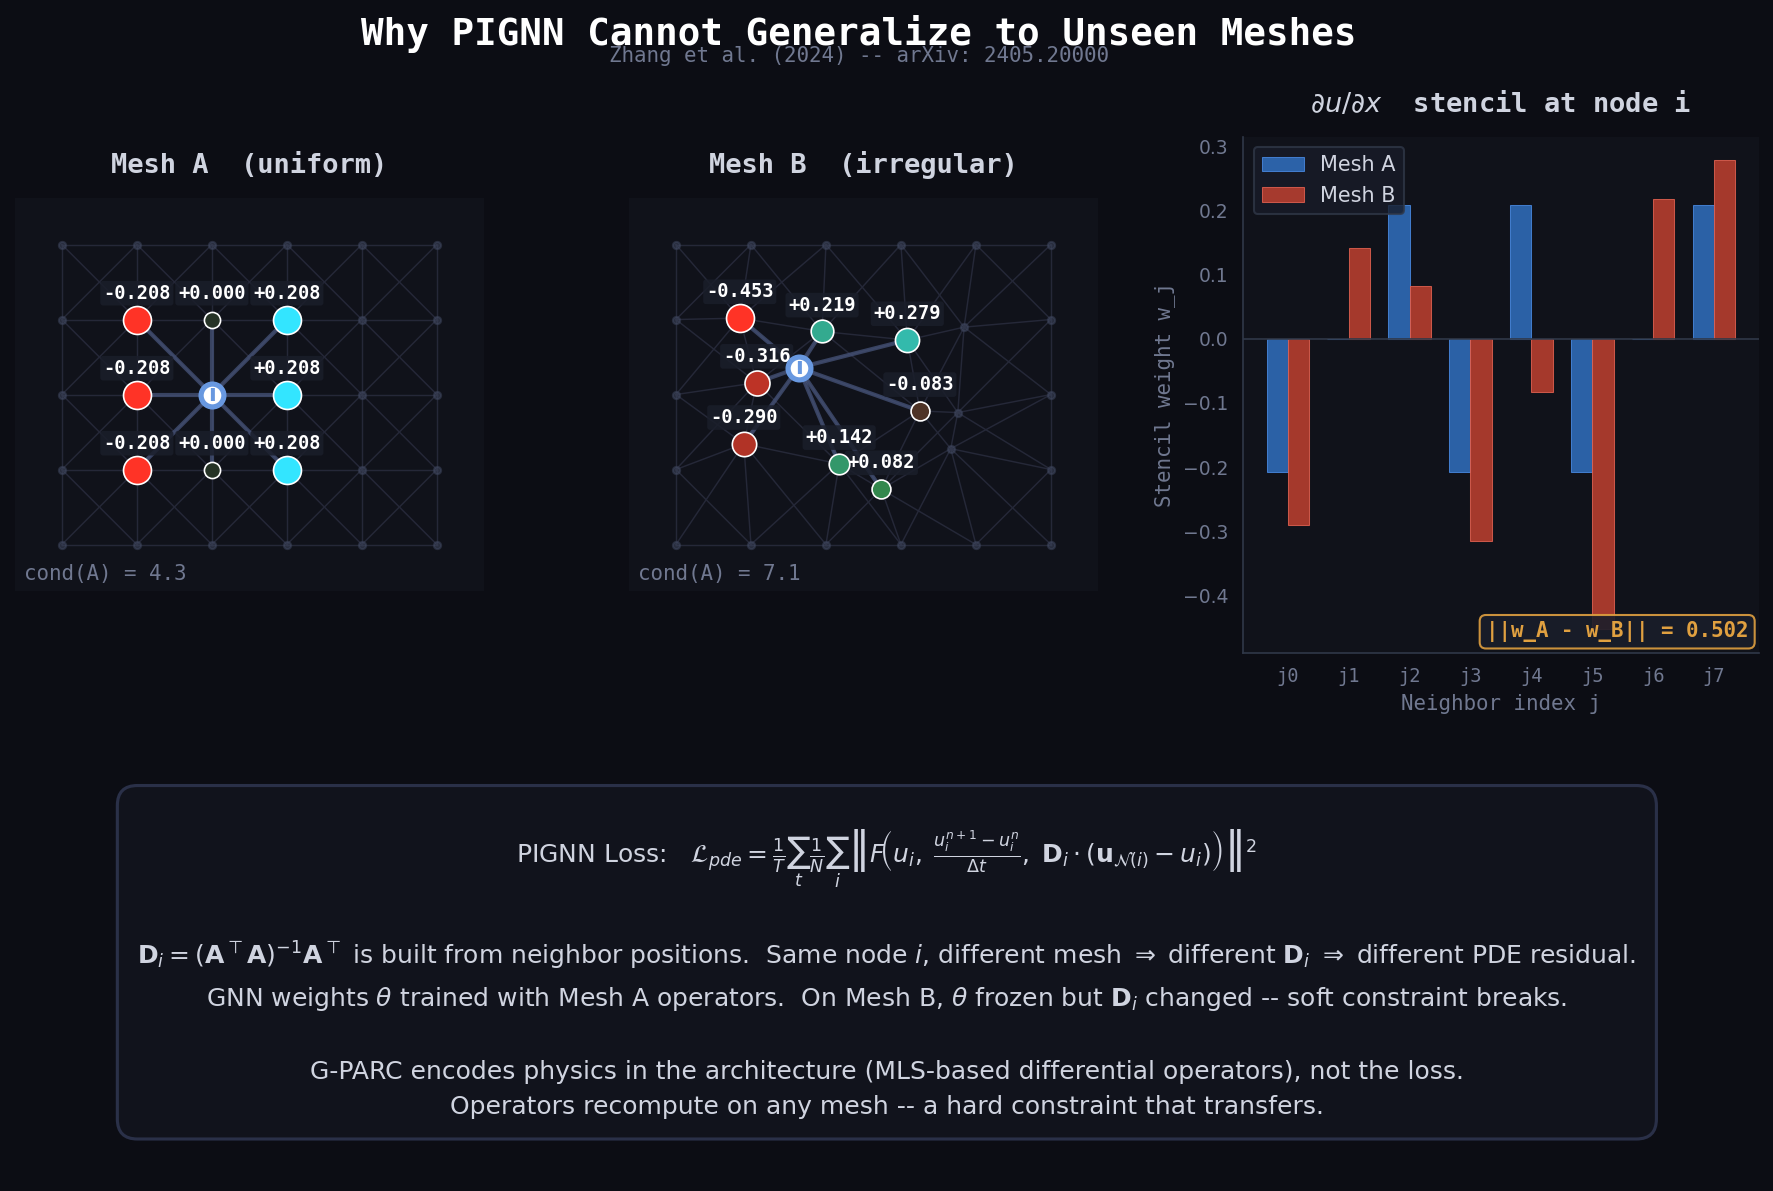

Node 14 stencil comparison:
  Mesh A weights: ['-0.2083', '+0.0000', '+0.2083', '-0.2083', '+0.2083', '-0.2083', '+0.0000', '+0.2083']
  Mesh B weights: ['-0.2900', '+0.1417', '+0.0819', '-0.3160', '-0.0829', '-0.4529', '+0.2190', '+0.2793']
  ||wA - wB|| = 0.5019
  cond(A): 4.3 vs 7.1 (1.6x)


In [12]:
%matplotlib inline

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec


# ── Mesh generation ──

def gen_uniform(nx, ny, w, h):
    x, y = np.linspace(0, w, nx+1), np.linspace(0, h, ny+1)
    xx, yy = np.meshgrid(x, y)
    nodes = np.column_stack([xx.ravel(), yy.ravel()])
    idx = lambda i, j: j*(nx+1)+i
    nbrs = {k: set() for k in range(len(nodes))}
    for j in range(ny+1):
        for i in range(nx+1):
            c = idx(i, j)
            for di, dj in [(-1,0),(1,0),(0,-1),(0,1),(-1,-1),(1,1),(1,-1),(-1,1)]:
                a, b = i+di, j+dj
                if 0 <= a <= nx and 0 <= b <= ny:
                    nbrs[c].add(idx(a, b))
    edges = set()
    for c, ns in nbrs.items():
        for n in ns:
            edges.add((min(c, n), max(c, n)))
    return nodes, nbrs, list(edges)


def gen_irregular(nx, ny, w, h, seed=42):
    rng = np.random.RandomState(seed)
    x, y = np.linspace(0, w, nx+1), np.linspace(0, h, ny+1)
    xx, yy = np.meshgrid(x, y)
    nodes = np.column_stack([xx.ravel(), yy.ravel()])
    for k in range(len(nodes)):
        i, j = k % (nx+1), k // (nx+1)
        if 0 < i < nx and 0 < j < ny:
            nodes[k, 0] += rng.uniform(-0.38, 0.38) * (w / nx)
            nodes[k, 1] += rng.uniform(-0.38, 0.38) * (h / ny)
    idx = lambda i, j: j*(nx+1)+i
    nbrs = {k: set() for k in range(len(nodes))}
    for j in range(ny+1):
        for i in range(nx+1):
            c = idx(i, j)
            for di, dj in [(-1,0),(1,0),(0,-1),(0,1),(-1,-1),(1,1),(1,-1),(-1,1)]:
                a, b = i+di, j+dj
                if 0 <= a <= nx and 0 <= b <= ny:
                    nbrs[c].add(idx(a, b))
    edges = set()
    for c, ns in nbrs.items():
        for n in ns:
            edges.add((min(c, n), max(c, n)))
    return nodes, nbrs, list(edges)


def fd_dudx(pos, nbr_pos):
    """OLS-based FD stencil for du/dx -- this is what PIGNN computes."""
    dx = nbr_pos[:, 0] - pos[0]
    dy = nbr_pos[:, 1] - pos[1]
    A = np.column_stack([dx, dy, 0.5*dx**2, dx*dy, 0.5*dy**2])
    return np.linalg.pinv(A)[0, :], np.linalg.cond(A)


# ── Build meshes and compute FD operators ──

nx, ny, w, h = 5, 4, 4.0, 3.2
nA, nbA, eA = gen_uniform(nx, ny, w, h)
nB, nbB, eB = gen_irregular(nx, ny, w, h)

hi = (ny // 2) * (nx + 1) + nx // 2   # pick an interior node
nlA = sorted(nbA[hi])
nlB = sorted(nbB[hi])
wA, cA = fd_dudx(nA[hi], nA[nlA])
wB, cB = fd_dudx(nB[hi], nB[nlB])
dn = np.linalg.norm(wA - wB)


# ── Drawing helpers ──

M  = '#d0d4e0'   # main text
D  = '#707890'   # dim text
AC = '#6898e0'   # accent
BG = '#10121a'   # axes bg
EC = '#252838'   # edge color
NC = '#404860'   # node color


def style_ax(ax):
    ax.set_facecolor(BG)
    for sp in ax.spines.values():
        sp.set_visible(False)
    ax.tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)


def draw_mesh(ax, nodes, edges, center, nbr_list, weights, title, cond_val):
    style_ax(ax)

    # draw all edges
    for a, b in edges:
        ax.plot([nodes[a, 0], nodes[b, 0]],
                [nodes[a, 1], nodes[b, 1]],
                color=EC, lw=0.7, zorder=1)

    # draw all nodes dimly
    ax.scatter(nodes[:, 0], nodes[:, 1], c=NC, s=12, zorder=2, alpha=0.5)

    # draw stencil connections
    for ni in nbr_list:
        ax.plot([nodes[center, 0], nodes[ni, 0]],
                [nodes[center, 1], nodes[ni, 1]],
                color='#4a5880', lw=2, zorder=3, alpha=0.7)

    # draw neighbor nodes colored by weight
    mx = np.max(np.abs(weights)) + 1e-12
    for j, ni in enumerate(nbr_list):
        ww = weights[j]
        t = abs(ww) / mx
        if ww > 0:
            clr = (0.2, 0.45 + 0.45*t, 0.85*t + 0.15)
        else:
            clr = (0.85*t + 0.15, 0.2, 0.15)
        ax.scatter(nodes[ni, 0], nodes[ni, 1], c=[clr],
                   s=60 + 120*t, zorder=5,
                   edgecolors='white', linewidths=0.8)
        ax.annotate('%+.3f' % ww,
                    (nodes[ni, 0], nodes[ni, 1]),
                    textcoords='offset points', xytext=(0, 10),
                    fontsize=9, color='white', ha='center',
                    fontfamily='monospace', fontweight='bold',
                    bbox=dict(boxstyle='round,pad=0.15',
                              fc='#1a1e2a', ec='none', alpha=0.85))

    # draw center node
    ax.scatter(nodes[center, 0], nodes[center, 1],
               c='white', s=120, zorder=6,
               edgecolors=AC, linewidths=2.5)
    ax.annotate('i', (nodes[center, 0], nodes[center, 1]),
                fontsize=11, color=AC, ha='center', va='center',
                fontweight='bold', zorder=7)

    ax.set_title(title, fontsize=13, color=M,
                 fontfamily='monospace', fontweight='bold', pad=12)
    ax.set_aspect('equal')
    pad = 0.5
    ax.set_xlim(nodes[:, 0].min() - pad, nodes[:, 0].max() + pad)
    ax.set_ylim(nodes[:, 1].min() - pad, nodes[:, 1].max() + pad)
    ax.text(0.02, 0.02, 'cond(A) = %.1f' % cond_val,
            transform=ax.transAxes, fontsize=10,
            color=D, fontfamily='monospace', va='bottom')


# ── Create figure ──

fig = plt.figure(figsize=(15, 9))
fig.patch.set_facecolor('#0c0d14')

gs = gridspec.GridSpec(2, 3, figure=fig,
                       width_ratios=[1, 1, 1.1],
                       height_ratios=[1.4, 1],
                       hspace=0.35, wspace=0.3)

# ── Panel 1: Mesh A (uniform) ──

ax1 = fig.add_subplot(gs[0, 0])
draw_mesh(ax1, nA, eA, hi, nlA, wA, 'Mesh A  (uniform)', cA)

# ── Panel 2: Mesh B (irregular) ──

ax2 = fig.add_subplot(gs[0, 1])
draw_mesh(ax2, nB, eB, hi, nlB, wB, 'Mesh B  (irregular)', cB)

# ── Panel 3: Bar chart comparison ──

ax3 = fig.add_subplot(gs[0, 2])
style_ax(ax3)
ax3.tick_params(labelleft=True, labelbottom=True)
ax3.spines['left'].set_visible(True)
ax3.spines['left'].set_color('#303848')
ax3.spines['bottom'].set_visible(True)
ax3.spines['bottom'].set_color('#303848')
ax3.tick_params(colors=D, labelsize=9)

xp = np.arange(len(wA))
bw = 0.35
ax3.bar(xp - bw/2, wA, bw,
        color='#3070c0', alpha=0.85, label='Mesh A',
        edgecolor='#4888e0', linewidth=0.5)
ax3.bar(xp + bw/2, wB, bw,
        color='#c04030', alpha=0.85, label='Mesh B',
        edgecolor='#e06050', linewidth=0.5)
ax3.axhline(0, color='#303848', lw=0.8)
ax3.set_xlabel('Neighbor index j', fontsize=10,
               color=D, fontfamily='monospace')
ax3.set_ylabel('Stencil weight w_j', fontsize=10,
               color=D, fontfamily='monospace')
ax3.set_title(r'$\partial u / \partial x$  stencil at node i',
              fontsize=13, color=M, fontfamily='monospace',
              fontweight='bold', pad=12)
ax3.set_xticks(xp)
ax3.set_xticklabels(['j%d' % k for k in range(len(wA))],
                     fontfamily='monospace')
ax3.legend(fontsize=10, loc='upper left', frameon=True,
           facecolor='#181c28', edgecolor='#303848', labelcolor=M)
ax3.text(0.98, 0.02,
         '||w_A - w_B|| = %.3f' % dn,
         transform=ax3.transAxes, fontsize=10, color='#e0a040',
         fontfamily='monospace', fontweight='bold',
         ha='right', va='bottom',
         bbox=dict(boxstyle='round,pad=0.3',
                   fc='#1a1e2a', ec='#e0a040', alpha=0.9))

# ── Panel 4: Loss equation + explanation ──

ax4 = fig.add_subplot(gs[1, :])
ax4.set_facecolor('#0c0d14')
for sp in ax4.spines.values():
    sp.set_visible(False)
ax4.tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)

txt = (
    r"PIGNN Loss:   $\mathcal{L}_{pde} = \frac{1}{T}\sum_t \frac{1}{N}\sum_i"
    r" \left\| F\!\left(u_i,\; \frac{u_i^{n+1} - u_i^n}{\Delta t},\;"
    r" \mathbf{D}_i \cdot (\mathbf{u}_{\mathcal{N}(i)} - u_i)\right)\right\|^2$"
    "\n\n"
    r"$\mathbf{D}_i = (\mathbf{A}^\top \mathbf{A})^{-1}\mathbf{A}^\top$"
    r" is built from neighbor positions.  Same node $i$, different mesh"
    r" $\Rightarrow$ different $\mathbf{D}_i$ $\Rightarrow$ different PDE residual."
    "\n"
    r"GNN weights $\theta$ trained with Mesh A operators."
    r"  On Mesh B, $\theta$ frozen but $\mathbf{D}_i$ changed"
    " -- soft constraint breaks."
    "\n\n"
    "G-PARC encodes physics in the architecture"
    " (MLS-based differential operators), not the loss.\n"
    "Operators recompute on any mesh"
    " -- a hard constraint that transfers."
)

ax4.text(0.5, 0.55, txt,
         transform=ax4.transAxes, fontsize=12, color=M,
         ha='center', va='center', linespacing=1.6,
         bbox=dict(boxstyle='round,pad=0.8',
                   fc='#11131c', ec='#2a3048', linewidth=1.5))

# ── Title ──

fig.suptitle('Why PIGNN Cannot Generalize to Unseen Meshes',
             fontsize=18, color='white', fontfamily='monospace',
             fontweight='bold', y=0.97)
fig.text(0.5, 0.935,
         'Zhang et al. (2024) -- arXiv: 2405.20000',
         ha='center', fontsize=10, color=D, fontfamily='monospace')

plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.show()

# ── Print summary ──
print('Node %d stencil comparison:' % hi)
print('  Mesh A weights:', ['%+.4f' % v for v in wA])
print('  Mesh B weights:', ['%+.4f' % v for v in wB])
print('  ||wA - wB|| = %.4f' % dn)
print('  cond(A): %.1f vs %.1f (%.1fx)' % (cA, cB, cB/cA))